# ✈️ Flight Delay Data Processing

This notebook performs **data cleaning, feature engineering, and exploration** on two raw datasets:

- `airports.csv` — metadata about airports (location, type, country, etc.)
- `Airports_Punctuality-Data.csv` — daily punctuality and delay statistics per airport

The goal is to produce a clean, enriched dataset (`cleaned_flight_data.csv`) ready for analysis and modeling of flight delays across six European countries (**France, Germany, Italy, Spain, Netherlands, United Kingdom**).

## 1. Import Libraries

Load the core libraries used throughout the notebook: **pandas** for tabular data manipulation, **numpy** for numerical operations, and **matplotlib** for visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load the Datasets

Read the two source CSV files into pandas DataFrames.

In [4]:
airports = pd.read_csv('airports.csv', low_memory=False)
delay = pd.read_csv('Airports_Punctuality-Data.csv')

## 3. Inspect Raw Data

Quickly preview the raw datasets **before any cleaning** to understand their structure, column names, and the kind of values they contain.

### 3.1 Airports dataset (raw)

In [5]:
print(airports)

           id    ident            type  \
0        6523      00A        heliport   
1      323361     00AA   small_airport   
2        6524     00AK   small_airport   
3        6525     00AL   small_airport   
4      506791     00AN   small_airport   
...       ...      ...             ...   
85526   32753     ZYYY  medium_airport   
85527   46378  ZZ-0001        heliport   
85528  307326  ZZ-0002   small_airport   
85529  346788  ZZ-0003   small_airport   
85530  599952  ZZ-0004        heliport   

                                                    name  latitude_deg  \
0                                      Total RF Heliport     40.070985   
1                                   Aero B Ranch Airport     38.704022   
2                                           Lowell Field     59.947733   
3                                           Epps Airpark     34.864799   
4                                   Katmai Lodge Airport     59.093287   
...                                                

### 3.2 Airports punctuality dataset (raw)

In [7]:
print(delay)

             Date   Airport Departure Punctuality % Arrival Punctuality %  \
0      2022-01-01  Brussels                  81.63%                77.63%   
1      2022-01-02  Brussels                  70.19%                69.90%   
2      2022-01-03  Brussels                  72.12%                75.47%   
3      2022-01-04  Brussels                  80.75%                80.95%   
4      2022-01-05  Brussels                  87.82%                82.59%   
...           ...       ...                     ...                   ...   
51606  2026-05-28  Istanbul                  91.73%                86.53%   
51607  2026-05-29  Istanbul                  90.54%                87.20%   
51608  2026-05-30  Istanbul                  90.88%                81.02%   
51609  2026-05-31  Istanbul                  82.17%                79.13%   
51610  2026-06-01  Istanbul                  93.15%                85.51%   

       Avg Departure Schedule Delay  Avg Arrival Schedule Delay  \
0       

## 4. Merge the Datasets

Join the punctuality records with airport metadata using an **inner join** on:

- `Airport` (from the punctuality dataset)
- `municipality` (from the airports dataset)

Only rows that match in both tables are kept.

In [59]:
df = pd.merge(delay,airports,left_on='Airport', right_on='municipality',how= 'inner')

## 5. Filter to Six European Countries

Restrict the analysis to airports located in **France (FR), Germany (DE), Italy (IT), Spain (ES), the Netherlands (NL), and the United Kingdom (GB)**.

In [60]:
#fltring dataset to 6 countries
countries = ['FR', 'DE', 'IT', 'ES', 'NL', 'GB']
df = df[df['iso_country'].isin(countries)]
print(df.tail(5))

              Date Airport Departure Punctuality % Arrival Punctuality %  \
175710  2026-05-28    Nice                  58.43%                72.66%   
175711  2026-05-29    Nice                  62.36%                72.86%   
175712  2026-05-30    Nice                  57.02%                75.21%   
175713  2026-05-31    Nice                  47.08%                59.07%   
175714  2026-06-01    Nice                  55.94%                59.11%   

        Avg Departure Schedule Delay  Avg Arrival Schedule Delay  \
175710                     24.074510                   15.379036   
175711                     18.536122                   12.899009   
175712                     19.698347                   12.388889   
175713                     30.408935                   20.270463   
175714                     20.902098                   18.422680   

        Avg Departure - Arrival Schedule Delay Operated Schedules %  \
175710                                8.695473               85

## 6. Data Cleaning

The following steps prepare the merged dataset for analysis:

1. Drop unnecessary columns and keep only the ones relevant to the analysis
2. Compute an `AverageDelay` feature
3. Handle missing values and duplicates
4. Remove statistical outliers using the IQR method

### 6.1 Select Relevant Columns

Keep only the columns that will be used downstream, dropping the rest to reduce noise and memory usage.

In [64]:
#Remove Unneccessary coulmns

selected_columns = [
    'Date', 'Airport', 'Departure Punctuality %', 'Arrival Punctuality %',
    'Avg Departure Schedule Delay', 'Avg Arrival Schedule Delay', 
    'Avg Departure - Arrival Schedule Delay', 'Operated Schedules %',
    'AverageDelay', 'type', 'latitude_deg', 'longitude_deg', 
    'elevation_ft', 'iso_country', 'municipality', 
    'Month', 'DayOfWeek', 'Weekend', 'Season', 'Airport_Size', 'Is_Delayed'
]

merged = merged[selected_columns]


print(merged.head())

            Date    Airport Departure Punctuality % Arrival Punctuality %  \
14517 2022-01-01  Frankfurt                  81.89%                80.42%   
14518 2022-01-02  Frankfurt                  70.72%                71.34%   
14519 2022-01-03  Frankfurt                  73.89%                75.60%   
14520 2022-01-04  Frankfurt                  63.05%                72.60%   
14521 2022-01-05  Frankfurt                  78.28%                82.20%   

       Avg Departure Schedule Delay  Avg Arrival Schedule Delay  \
14517                     13.043920                   13.426908   
14518                     17.652062                   18.506590   
14519                     16.235140                   13.956209   
14520                     16.605624                   14.621955   
14521                     10.382379                    9.699187   

       Avg Departure - Arrival Schedule Delay Operated Schedules %  \
14517                               -0.382988               92.2

### 6.2 Create the `AverageDelay` Feature

Define **average delay** as the mean of the average *departure* schedule delay and the average *arrival* schedule delay.

In [62]:
merged['AverageDelay'] = (merged['Avg Departure Schedule Delay'] + merged['Avg Arrival Schedule Delay']) / 2

### 6.3 Handle Missing Values and Duplicates

- Drop rows where `AverageDelay` is missing (target variable cannot be inferred)
- Fill remaining numerical NaNs with the **median** of each numeric column (robust to outliers)
- Remove duplicate rows

In [37]:
merged = merged.dropna(subset=['AverageDelay'])

In [38]:
num_cols = merged.select_dtypes(include=[np.number]).columns

In [39]:
merged[num_cols] = merged[num_cols].fillna(merged[num_cols].median())

In [40]:
merged = merged.drop_duplicates()

### 6.4 Outlier Handling — IQR Method

Use the **Interquartile Range (IQR)** rule to filter extreme delay values:

$$
\text{Lower} = Q_1 - 1.5 \times IQR \qquad \text{Upper} = Q_3 + 1.5 \times IQR
$$

Any record with `AverageDelay` outside `[Lower, Upper]` is treated as an outlier and excluded from `merged_clean`.

In [43]:
Q1 = merged['AverageDelay'].quantile(0.25)
Q3 = merged['AverageDelay'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

merged_clean = merged[(merged['AverageDelay'] >= lower) & (merged['AverageDelay'] <= upper)]

## 7. Feature Engineering

Create new features that will be useful for analysis and modeling:

- **Date features** — Month, day of week, weekend flag
- **Season** — Winter / Spring / Summer / Fall
- **Airport size** — Large / Medium / Small / Other
- **Target variable** — `Is_Delayed` (1 if delay > 15 minutes, else 0)

### 7.1 Date-Based Features

Parse `Date` as a datetime, then derive the **month**, **day name**, and a binary **weekend** indicator (Saturday/Sunday → 1).

In [45]:
#Date Feature 
merged['Date'] = pd.to_datetime(merged['Date'])
merged['Month'] = merged['Date'].dt.month
merged['DayOfWeek'] = merged['Date'].dt.day_name()

def determine_weekend(day_name):
    if day_name == 'Saturday':
        return 1
    elif day_name == 'Sunday':
        return 1
    else:
        return 0

merged['Weekend'] = merged['DayOfWeek'].apply(determine_weekend)

### 7.2 Season Feature

Map each month to a meteorological **season**:

| Months | Season |
|---|---|
| 12, 1, 2 | Winter |
| 3, 4, 5 | Spring |
| 6, 7, 8 | Summer |
| 9, 10, 11 | Fall |

In [46]:
#Season feature

def determine_season(month_number):
    if month_number == 12 or month_number == 1 or month_number == 2:
        return 'Winter'
    elif month_number == 3 or month_number == 4 or month_number == 5:
        return 'Spring'
    elif month_number == 6 or month_number == 7 or month_number == 8:
        return 'Summer'
    else:
        return 'Fall'

merged['Season'] = merged['Month'].apply(determine_season)

### 7.3 Categorical Binning — Airport Size

Group the raw `type` field into four readable buckets: **Large**, **Medium**, **Small**, or **Other**.

In [50]:
#catagorial binning 

def determine_airport_size(airport_type):
    if airport_type == 'large_airport':
        return 'Large'
    elif airport_type == 'medium_airport':
        return 'Medium'
    elif airport_type == 'small_airport':
        return 'Small'
    else:
        return 'Other'

merged['Airport_Size'] = merged['type'].apply(determine_airport_size)      

### 7.4 Target Variable — `Is_Delayed`

Following the common industry convention, a flight is considered **delayed** when its average delay exceeds **15 minutes**.

- `1` → delayed
- `0` → on time

In [51]:
#Target Variable


def determine_delay_status(delay_minutes):
    if delay_minutes > 15:
        return 1
    else:
        return 0

merged['Is_Delayed'] = merged['AverageDelay'].apply(determine_delay_status)

## 8. Visualization — Distribution of Average Delays

Plot a histogram to see how `AverageDelay` is distributed after cleaning. This helps spot skewness, central tendency, and the overall shape of the delay distribution.

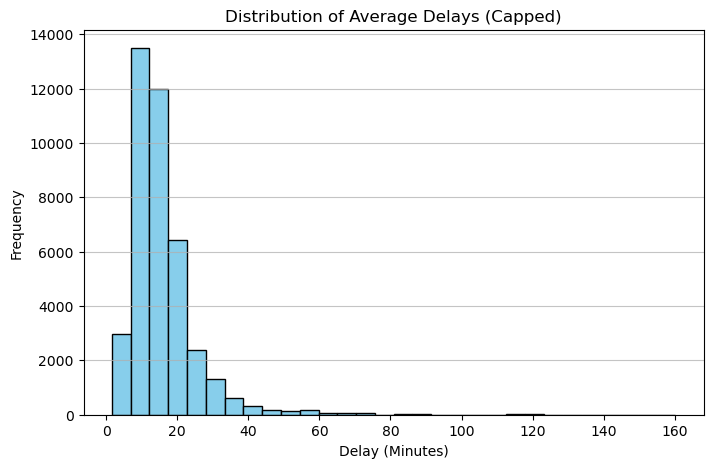

In [66]:
#Visulization

%matplotlib inline
plt.figure(figsize=(8, 5))
plt.hist(merged['AverageDelay'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Average Delays (Capped)')
plt.xlabel('Delay (Minutes)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## 9. Final Dataset Overview

Check the schema and non-null counts of the cleaned, feature-engineered DataFrame to confirm everything is in order before exporting.

In [69]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40323 entries, 14517 to 175714
Data columns (total 21 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   Date                                    40323 non-null  datetime64[ns]
 1   Airport                                 40323 non-null  object        
 2   Departure Punctuality %                 40323 non-null  object        
 3   Arrival Punctuality %                   40323 non-null  object        
 4   Avg Departure Schedule Delay            40323 non-null  float64       
 5   Avg Arrival Schedule Delay              40323 non-null  float64       
 6   Avg Departure - Arrival Schedule Delay  40323 non-null  float64       
 7   Operated Schedules %                    40323 non-null  object        
 8   AverageDelay                            40323 non-null  float64       
 9   type                                    40323 non-

## 10. Save the Cleaned Dataset

Export the processed DataFrame to `cleaned_flight_data.csv` so it can be reused by downstream analysis and modeling notebooks.

In [70]:
#save cleaned dataset

merged.to_csv('cleaned_flight_data.csv', index=False)
print("Datas Processed and saved")

Datas Processed and saved
